In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
!pip install arch
from arch import arch_model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 26.2 MB/s eta 0:00:00


**Load and Read Data**

In [ ]:
#Load and Read file
df = pd.read_excel("/content/Exchange rates data.xlsx")

In [ ]:
df.shape

(318, 2)

In [ ]:
df.head()

,Months,Exchange Rates
0,2000-01-01,51.770247
1,2000-02-01,51.796174
2,2000-03-01,51.791234
3,2000-04-01,51.791144
4,2000-05-01,51.797450


In [ ]:
# Convert Months column to datetime
df['Months'] = pd.to_datetime(df['Months'])
# Set Months as index
df.set_index('Months', inplace=True)


In [ ]:
df.head()

,Exchange Rates
Months,
2000-01-01,51.770247
2000-02-01,51.796174
2000-03-01,51.791234
2000-04-01,51.791144
2000-05-01,51.797450


In [ ]:
# Log returns (%)
df['log_return'] = 100 * np.log(df['Exchange Rates'] / df['Exchange Rates'].shift(1))

In [ ]:
df.head()

,Exchange Rates,log_return
Months,,
2000-01-01,51.770247,NaN
2000-02-01,51.796174,0.050068
2000-03-01,51.791234,-0.009538
2000-04-01,51.791144,-0.000174
2000-05-01,51.797450,0.012175


In [ ]:
# Remove the first missing value
df = df.dropna()


In [ ]:
df.head()

,Exchange Rates,log_return
Months,,
2000-02-01,51.796174,0.050068
2000-03-01,51.791234,-0.009538
2000-04-01,51.791144,-0.000174
2000-05-01,51.797450,0.012175
2000-06-01,52.045200,0.477165


**Exploratory Data Analysis**

**Plot the time series**

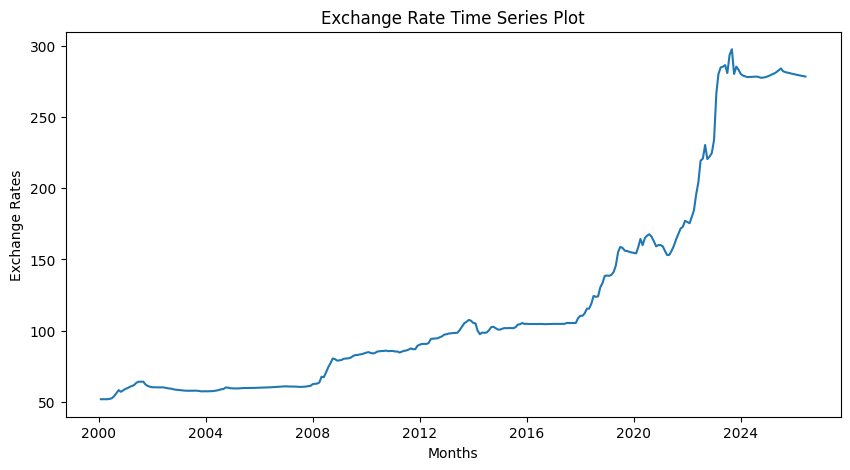

In [ ]:
ts = df['Exchange Rates']
plt.figure(figsize=(10,5))
plt.plot(ts)
plt.title("Exchange Rate Time Series Plot")
plt.xlabel("Months")
plt.ylabel("Exchange Rates")
plt.show()

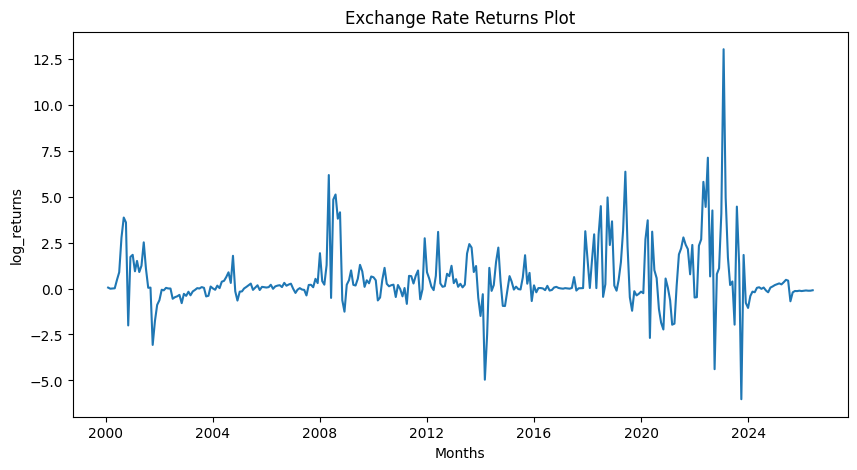

In [ ]:
ts_diff = df['log_return']
plt.figure(figsize=(10,5))
plt.plot(ts_diff)
plt.title("Exchange Rate Returns Plot")
plt.xlabel("Months")
plt.ylabel("log_returns")
plt.show()

**Check Stationarity (ADF Test)**

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_diff)

print("ADF Statistic:", result[0])
print("p-value حدی", result[1])

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary")

ADF Statistic: -3.894336318182599
p-value حدی 0.0020769263268491955
Series is stationary


**Plot ACF and PACF**

---



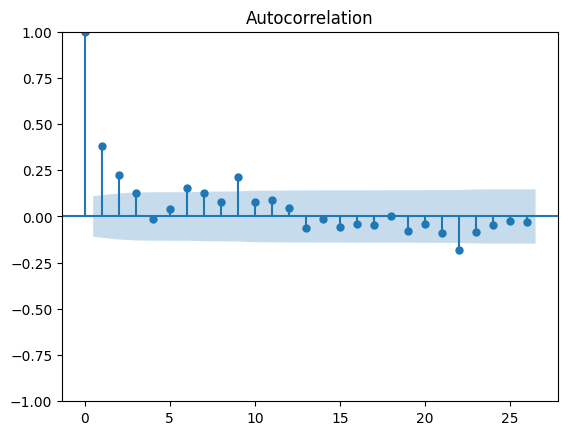

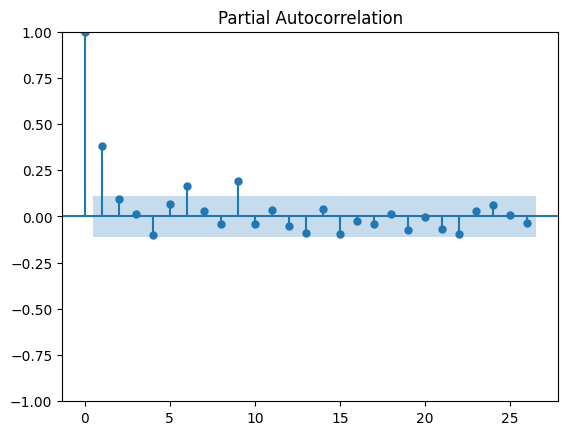

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ts_diff)
plt.show()

plot_pacf(ts_diff)
plt.show()



**Perform Engle's ARCH LM Test**

In [ ]:
from statsmodels.stats.diagnostic import het_arch

# Perform ARCH LM test
lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(df['log_return'])

print("ARCH LM Statistic:", lm_stat)
print("LM p-value:", lm_pvalue)
print("F Statistic:", f_stat)
print("F p-value:", f_pvalue)

ARCH LM Statistic: 41.95377755970116
LM p-value: 7.642020300127909e-06
F Statistic: 4.68534055808652
F p-value: 3.192568812191386e-06


In [ ]:
alpha = 0.05

if lm_pvalue < alpha:
    print("Reject H0: ARCH effects exist. A GARCH model is appropriate.")
else:
    print("Fail to reject H0: No significant ARCH effects detected.")

Reject H0: ARCH effects exist. A GARCH model is appropriate.


**Perform Normality Test**

In [ ]:
from scipy.stats import jarque_bera
# Jarque-Bera test
jb_stat, jb_pvalue = jarque_bera(df['log_return'])
print("Jarque-Bera Statistic:", jb_stat)
print("p-value:", jb_pvalue)

Jarque-Bera Statistic: 1908.2777049882782
p-value: 0.0


In [ ]:
if jb_pvalue < 0.05:
    print("Reject H0: Data are NOT normally distributed.")
else:
    print("Fail to reject H0: Data appear normally distributed.")

Reject H0: Data are NOT normally distributed.


**Fit AR(1)-GARCH(1,1)**

In [ ]:
# Fit AR(1)-GARCH(1,1)
model = arch_model(
    df['log_return'],
    mean="AR",      # AR mean model
    lags=1,         # AR(1)
    vol="GARCH",    # GARCH model
    p=1,            # ARCH order
    q=1,            # GARCH order
    dist="normal"
)

results = model.fit()

print(results.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 2342.721240964822
Iteration:      2,   Func. Count:     19,   Neg. LLF: 31083294191.79909
Iteration:      3,   Func. Count:     27,   Neg. LLF: 1716969492.3286676
Iteration:      4,   Func. Count:     35,   Neg. LLF: 577.851660367417
Iteration:      5,   Func. Count:     42,   Neg. LLF: 739.340990548257
Iteration:      6,   Func. Count:     49,   Neg. LLF: 470.493886885713
Iteration:      7,   Func. Count:     56,   Neg. LLF: 472.61165237314015
Iteration:      8,   Func. Count:     63,   Neg. LLF: 466.5766047165787
Iteration:      9,   Func. Count:     69,   Neg. LLF: 466.53867700123715
Iteration:     10,   Func. Count:     75,   Neg. LLF: 466.53593752012864
Iteration:     11,   Func. Count:     81,   Neg. LLF: 466.53538491141427
Iteration:     12,   Func. Count:     87,   Neg. LLF: 466.53534095770533
Iteration:     13,   Func. Count:     93,   Neg. LLF: 466.5353394128417
Iteration:     14,   Func. Count:     98,   Neg. LLF: 466.535

**Check Diagnostics**

In [ ]:
df['std_resid'] = std_resid

In [ ]:
df.head()

,Exchange Rates,log_return,std_resid
Months,,,
2000-02-01,51.796174,0.050068,NaN
2000-03-01,51.791234,-0.009538,-0.078833
2000-04-01,51.791144,-0.000174,-0.059554
2000-05-01,51.797450,0.012175,-0.064720
2000-06-01,52.045200,0.477165,0.546079


In [ ]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(std_resid.dropna())

print("Jarque-Bera Statistic:", jb_stat)
print("p-value:", jb_pvalue)

Jarque-Bera Statistic: 727.0085993995349
p-value: 1.3554655752579969e-158


In [ ]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(std_resid.dropna())

print("LM Statistic:", arch_test[0])
print("LM p-value:", arch_test[1])

LM Statistic: 2.5365426822995154
LM p-value: 0.9903324366705427


**Forecast Volatility**

In [ ]:
forecast = results.forecast(horizon=6)

print("Forecasted Variance:")
print(forecast.variance)

print("Forecasted Mean:")
print(forecast.mean)

Forecasted Variance:
                 h.1       h.2       h.3       h.4       h.5       h.6
Months                                                                
2026-06-01  0.236045  0.398603  0.539177  0.673175  0.805206  0.936649
Forecasted Mean:
                 h.1      h.2       h.3       h.4       h.5       h.6
Months                                                               
2026-06-01  0.016905  0.07815  0.111648  0.129968  0.139989  0.145469


**Plot Conditional Volatility**

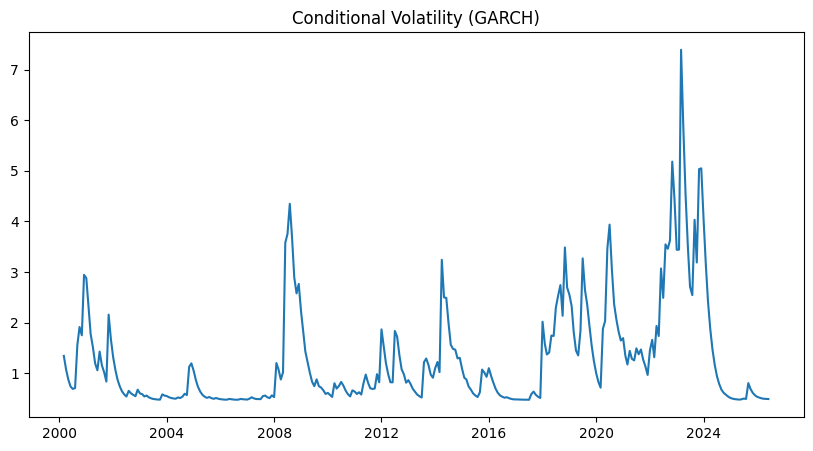

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(results.conditional_volatility)
plt.title("Conditional Volatility (GARCH)")
plt.show()